In [1]:
import pandas as pd


data = pd.read_csv('data/RNA-Seq-expression-Norilsk2019.csv')

In [2]:
data

,Gene,Species,log_2 fold change,Adjusted p-value
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84
...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asumiendo que tu DataFrame se llama "data"
df = data.copy()

# Umbrales definidos
fc_threshold = 1.5  # Cambio de al menos 2^(1.5) ≈ 2.8 veces
pval_threshold = 0.05

# Clasificación
df['Significativo'] = 'No significativo'
df.loc[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sobre-expresado'
df.loc[(df['log_2 fold change'] <= -fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sub-expresado'


In [4]:
genes_up = df[(df['log_2 fold change'] > 0) & (df['Significativo'] == 'Sobre-expresado')]
gene_ids = genes_up['Gene'].tolist()


In [16]:
import requests

string_api_url = "https://string-db.org/api"
output_format = "tsv-no-header"
method = "network"

# Reemplaza con tu lista de genes convertidos a símbolos si es necesario
genes_str = "%0d".join(gene_ids)  # formateo para múltiples genes

params = {
    "identifiers": genes_str,
    "species": 9606,  # Homo sapiens
    "caller_identity": "tu_nombre_o_correo"
}

response = requests.post(f"{string_api_url}/{output_format}/{method}", data=params)

# Guarda el archivo si es necesario o procesa directamente:
with open("string_interactions.tsv", "w") as f:
    f.write(response.text)


In [7]:
import pandas as pd
import networkx as nx

# Cargar archivo STRING
df_net = pd.read_csv("string_interactions.tsv", sep="\t", header=None)
G = nx.Graph()

# Agrega nodos y aristas
for _, row in df_net.iterrows():
    G.add_edge(row[2], row[3], weight=row[5])  # ajusta columnas si es necesario


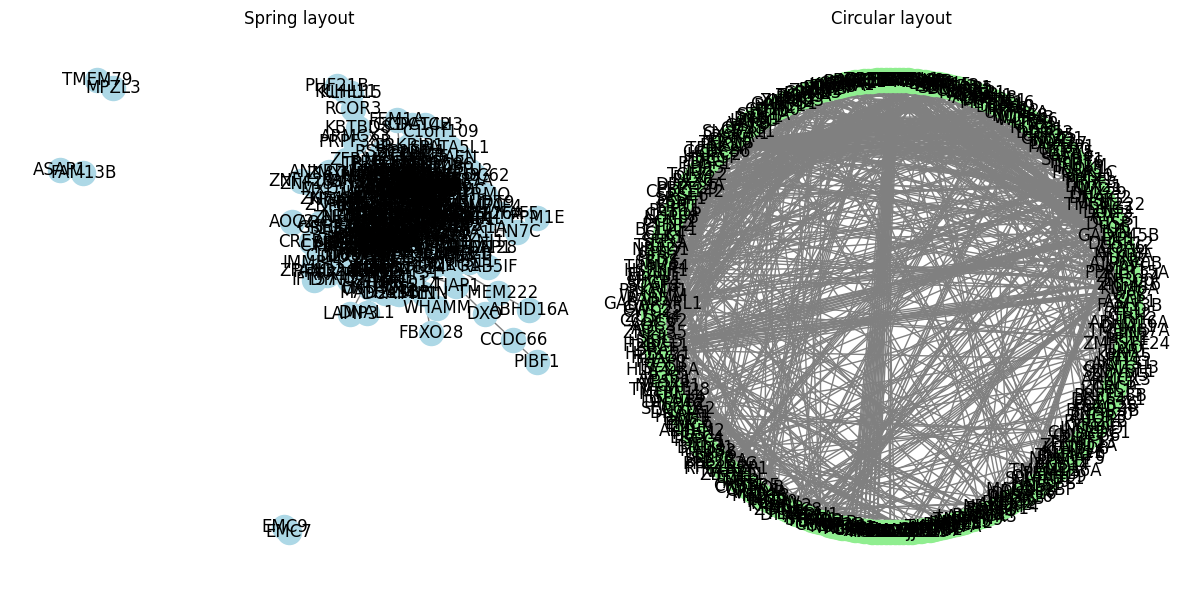

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Layout 1: Spring
plt.subplot(1, 2, 1)
pos1 = nx.spring_layout(G)
nx.draw(G, pos1, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Spring layout")

# Layout 2: Circular
plt.subplot(1, 2, 2)
pos2 = nx.circular_layout(G)
nx.draw(G, pos2, with_labels=True, node_color='lightgreen', edge_color='gray')
plt.title("Circular layout")

plt.tight_layout()
plt.show()


In [9]:
clustering = nx.average_clustering(G)
grado_promedio = sum(dict(G.degree()).values()) / len(G)
diametro = nx.diameter(G) if nx.is_connected(G) else "No conexa"
long_camino_prom = nx.average_shortest_path_length(G) if nx.is_connected(G) else "No conexa"
geodesica = nx.diameter(G) if nx.is_connected(G) else "No conexa"


In [10]:
if nx.is_connected(G):
    max_len = 0
    path_geodesico = []
    for n1 in G.nodes():
        for n2 in G.nodes():
            try:
                path = nx.shortest_path(G, n1, n2)
                if len(path) > max_len:
                    max_len = len(path)
                    path_geodesico = path
            except nx.NetworkXNoPath:
                continue
    print("Nodos en la geodésica:", path_geodesico)


In [11]:
from mygene import MyGeneInfo
mg = MyGeneInfo()

converted = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol', species='human')
symbols = [item['symbol'] for item in converted if 'symbol' in item]


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
8 input query terms found dup hits:	[('ENSG00000137959', 5), ('ENSG00000165949', 4), ('ENSG00000137965', 4), ('ENSG00000187608', 2), ('E


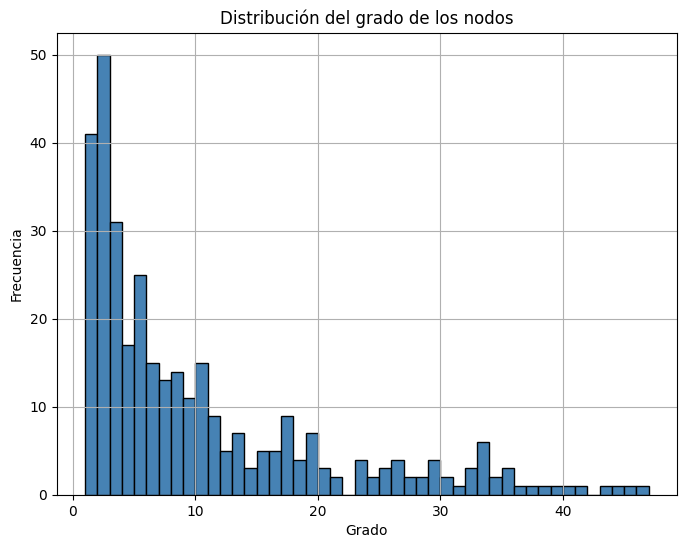

In [12]:
import matplotlib.pyplot as plt

degrees = [deg for _, deg in G.degree()]
plt.figure(figsize=(8, 6))
plt.hist(degrees, bins=range(1, max(degrees)+2), color='steelblue', edgecolor='black')
plt.title("Distribución del grado de los nodos")
plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

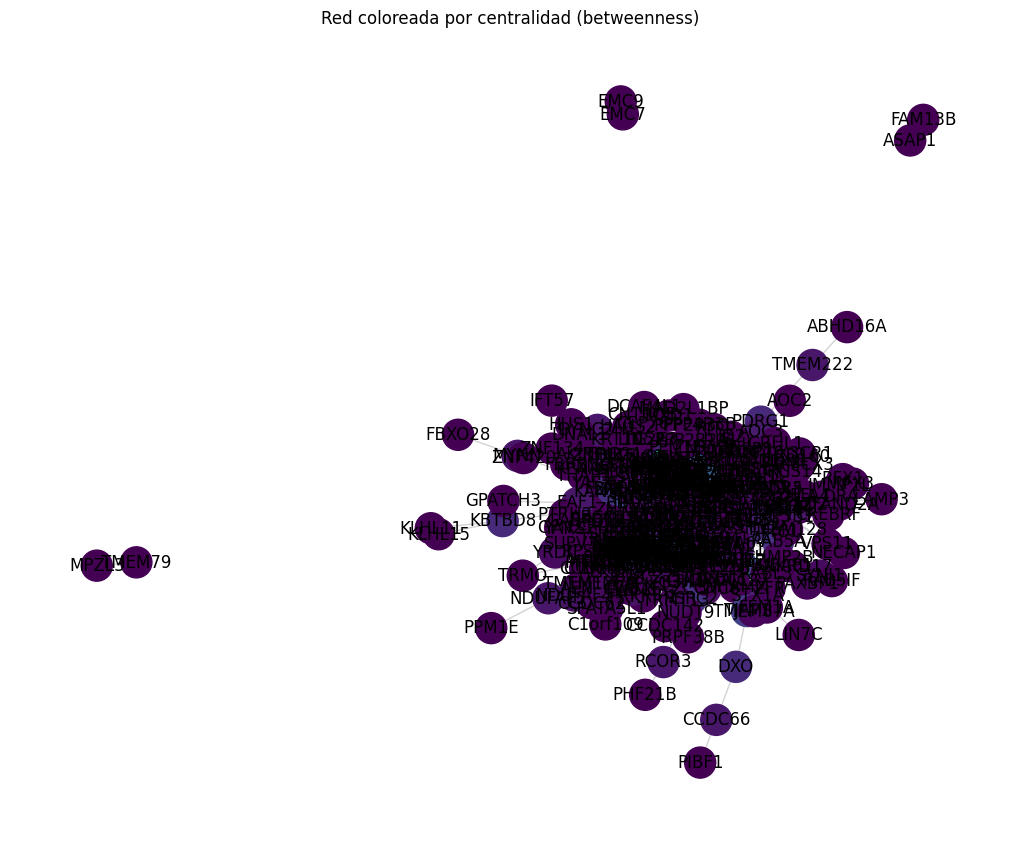

In [13]:
centrality = nx.betweenness_centrality(G)
node_color = [centrality[node] for node in G.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=node_color, cmap='viridis', edge_color='lightgray', node_size=500)
plt.title("Red coloreada por centralidad (betweenness)")
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), label='Centralidad')
plt.show()


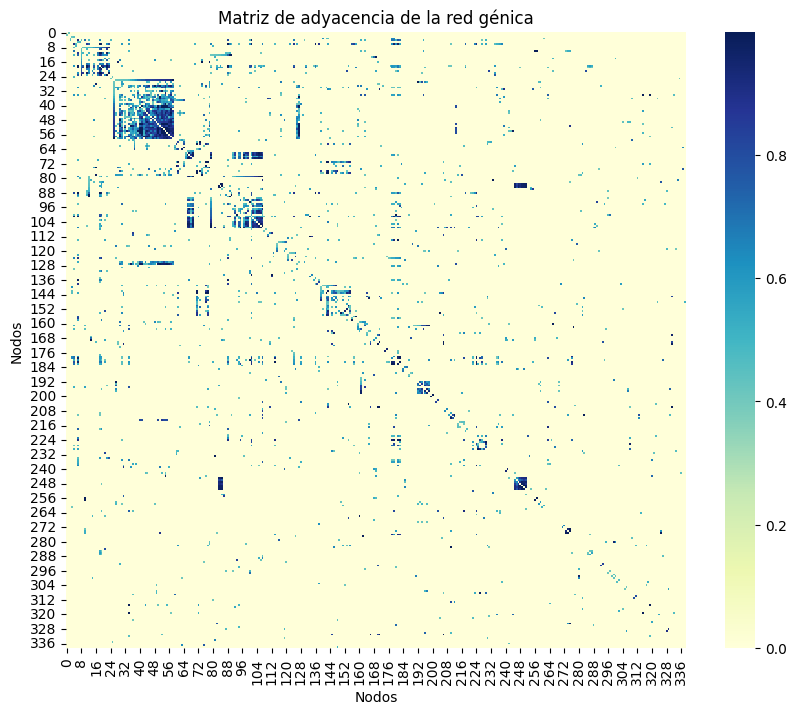

In [14]:
import numpy as np
import seaborn as sns

A = nx.to_numpy_array(G)
plt.figure(figsize=(10, 8))
sns.heatmap(A, cmap="YlGnBu")
plt.title("Matriz de adyacencia de la red génica")
plt.xlabel("Nodos")
plt.ylabel("Nodos")
plt.show()


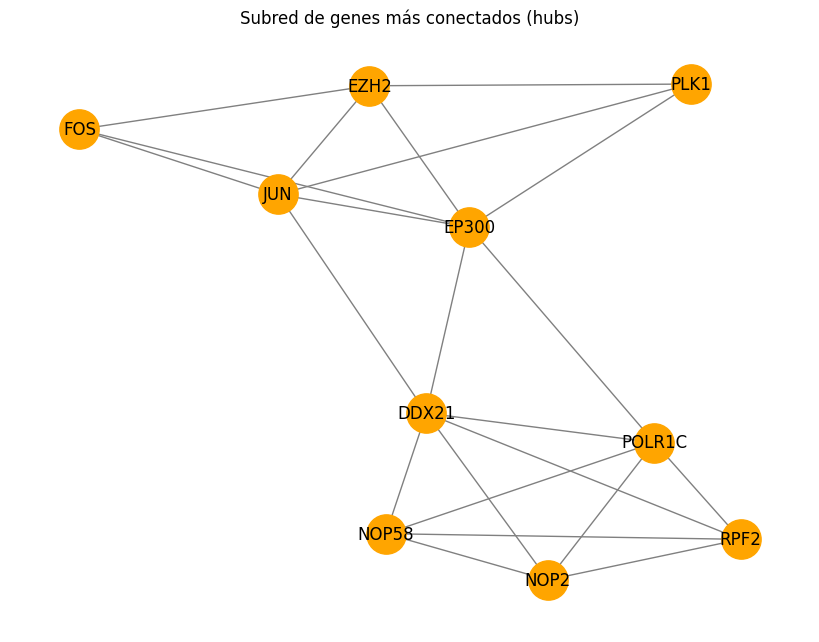

In [15]:
from operator import itemgetter

# Top 10 nodos con mayor grado
top_nodes = sorted(G.degree, key=itemgetter(1), reverse=True)[:10]
top_node_names = [n for n, _ in top_nodes]

# Subgrafo
subG = G.subgraph(top_node_names)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG)
nx.draw(subG, pos, with_labels=True, node_color='orange', edge_color='gray', node_size=800)
plt.title("Subred de genes más conectados (hubs)")
plt.show()
